In [93]:
import pandas as pd

In [94]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [95]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [96]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [97]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [98]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [99]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [100]:
df['TotalCharges'].head(20)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: str

In [101]:
df['TotalCharges'].str.strip().eq('').sum()

np.int64(11)

In [102]:
df[df['TotalCharges'].str.strip()==''][['customerID','tenure','TotalCharges','Churn']]

,customerID,tenure,TotalCharges,Churn
488,4472-LVYGI,0,,No
753,3115-CZMZD,0,,No
936,5709-LVOEQ,0,,No
1082,4367-NUYAO,0,,No
1340,1371-DWPAZ,0,,No
3331,7644-OMVMY,0,,No
3826,3213-VVOLG,0,,No
4380,2520-SGTTA,0,,No
5218,2923-ARZLG,0,,No
6670,4075-WKNIU,0,,No


In [103]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [104]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [105]:
df['TotalCharges']=df['TotalCharges'].fillna(0)

In [106]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [107]:
df['TotalCharges'].dtype

dtype('float64')

In [108]:
df['customerID'].duplicated().sum()

np.int64(0)

In [109]:
# what percentage of customers are churning
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [110]:
# Percentage of customers who churned and stayed, separately for each contract
pd.crosstab(df['Contract'], df['Churn'], normalize='index')*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [111]:
# What is the average number of months that customers stayed with the company,
#  separately for customers who churned and customers who stayed?
df.groupby('Churn')['tenure'].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

Customers with shorter tenure appear more likely to churn, while customers who stay tend to have longer relationships with the company.

In [112]:
# How many customers are in each contract type?
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [113]:
# The largest customer segment is also the segment with by far the highest churn rate.

In [114]:
# find the churn count within each contract
pd.crosstab(df['Contract'],df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [115]:
# almost 90% of all the churned customers coming from the month-to-month contract type.
#  This is a very important insight for the business. 
# The company should focus on retaining customers with month-to-month contracts, 
# as they are more likely to churn compared to customers with one-year or two-year contracts.

In [116]:
# Does the type of internet service have a relationship with churn?
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [117]:
pd.crosstab(df['InternetService'], df['Churn'])

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [118]:
pd.crosstab(df['InternetService'],df['Churn'],normalize='index')*100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [119]:
# Fiber optic customers show a substantially higher churn rate than other 
# internet-service groups.

In [120]:
# Within each combination of contract type and internet service,
#  what percentage of customers churn?

pd.crosstab([df['Contract'],df['InternetService']],df['Churn'],normalize ='index')*100

Churn                                  No        Yes
Contract       InternetService                      
Month-to-month DSL              67.784137  32.215863
               Fiber optic      45.394737  54.605263
               No               81.106870  18.893130
One year       DSL              90.701754   9.298246
               Fiber optic      80.705009  19.294991
               No               97.527473   2.472527
Two year       DSL              98.089172   1.910828
               Fiber optic      92.773893   7.226107
               No               99.216301   0.783699

In [121]:
# combination of contract + service type gives us much more information
#  than either variable alone.
# This is called segmentation.
# Instead of treating all customers as one big group, 
# we're breaking them into meaningful groups.

In [122]:
df['MonthlyCharges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [123]:
# Do customers who pay more each month churn more?
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [124]:
# Higher monthly charges are associated with higher churn in this dataset.
# customers who churned were paying, on average, about $13.18 more per month

In [125]:
# Do customers who churn have different total charges from customers who stay?
df.groupby('Churn')['TotalCharges'].mean()

Churn
No     2549.911442
Yes    1531.796094
Name: TotalCharges, dtype: float64

In [126]:
# So customers who churned have lower average total charges.

# At first, that might seem strange because we just found that churned customers have higher monthly charges.

# But think about what TotalCharges actually represents:

# TotalCharges = how much the customer has paid since they joined.

In [127]:
# Does the way customers pay relate to churn?
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [128]:
pd.crosstab(df['PaymentMethod'],df['Churn'],normalize='index').round(3)*100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.3,16.7
Credit card (automatic),84.8,15.2
Electronic check,54.7,45.3
Mailed check,80.9,19.1


In [129]:
# Electronic-check customers show substantially higher churn than 
# customers using other payment methods.


In [130]:
# Is electronic-check churn still high when we break it down by contract type?
pd.crosstab([df['Contract'],df['PaymentMethod']],df['Churn'],normalize='index').round(3)*100

Churn                                       No   Yes
Contract       PaymentMethod                        
Month-to-month Bank transfer (automatic)  65.9  34.1
               Credit card (automatic)    67.2  32.8
               Electronic check           46.3  53.7
               Mailed check               68.4  31.6
One year       Bank transfer (automatic)  90.3   9.7
               Credit card (automatic)    89.7  10.3
               Electronic check           81.6  18.4
               Mailed check               93.2   6.8
Two year       Bank transfer (automatic)  96.6   3.4
               Credit card (automatic)    97.8   2.2
               Electronic check           92.3   7.7
               Mailed check               99.2   0.8

Electronic-check customers show higher churn across contract types, with the strongest risk appearing among month-to-month electronic-check customers at 53.7%.

In [131]:
### VISUALIZATION
churn_by_contract=pd.crosstab(df['Contract'],df['Churn'],normalize='index')*100

In [132]:
churn_by_contract

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


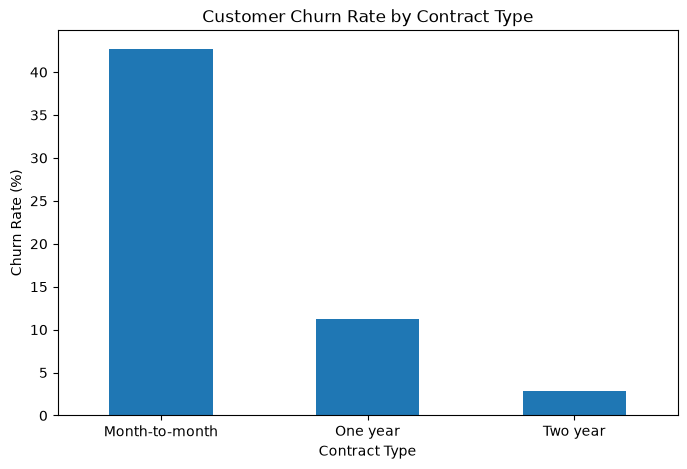

In [133]:
import matplotlib.pyplot as plt

churn_by_contract['Yes'].plot(kind='bar',
figsize=(8,5),
title='Customer Churn Rate by Contract Type'
)
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
plt.xticks(rotation=0)
plt.show()


this shows the percentage of customers within each contract type who churned 

In [134]:
churn_by_payment = pd.crosstab(df['PaymentMethod'],df['Churn'],normalize='index')*100
churn_by_payment

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


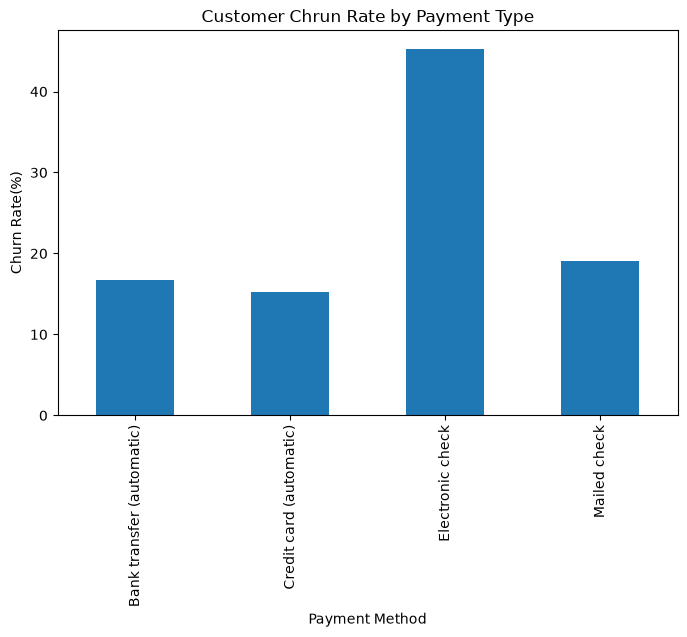

In [135]:
churn_by_payment['Yes'].plot(kind='bar',figsize=(8,5)     
                             )
plt.title('Customer Chrun Rate by Payment Type')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate(%)')
plt.xticks(rotation=90)
plt.show()

Electronic check customers have the highest churn rate (45.3%) ie 45 out of every 100 electronic check cutomers get churned, which is more than twice the churn rate of customers using mailed checked and automatic payment methods.

In [136]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [137]:
bins=[0,12,24,36,48,60,72]
labels=[
    '0-12 months',
    '13-24 months',
    '25-36 months',
    '37-48 months',
    '49-60 months',
    '61-72 months'
]

df['TenureGroup']=pd.cut(
    df['tenure'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [138]:
churn_by_tenure=pd.crosstab(df['TenureGroup'],df['Churn'],normalize='index')*100
churn_by_tenure.round(2)

Churn,No,Yes
TenureGroup,,
0-12 months,52.56,47.44
13-24 months,71.29,28.71
25-36 months,78.37,21.63
37-48 months,80.97,19.03
49-60 months,85.58,14.42
61-72 months,93.39,6.61


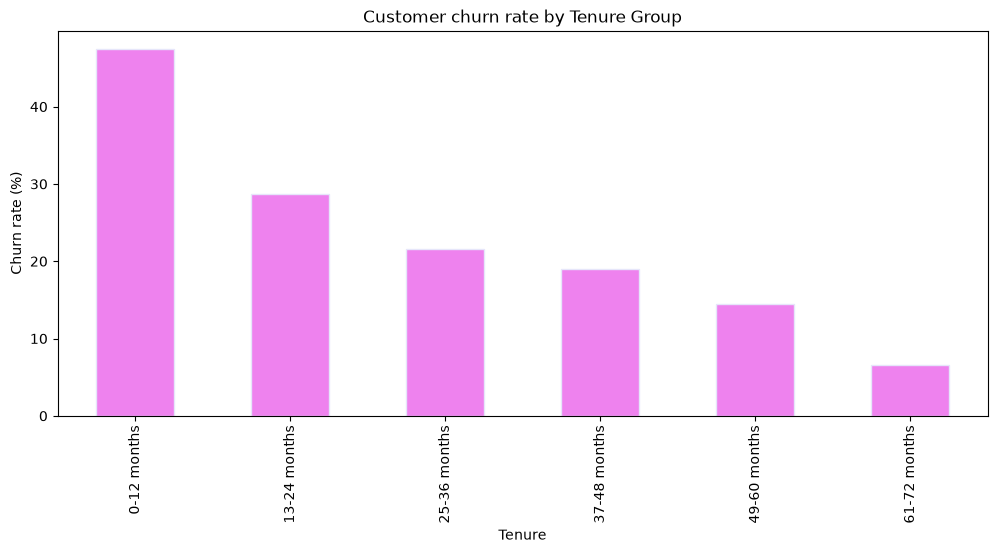

In [139]:
churn_by_tenure['Yes'].plot(kind='bar',figsize=(12,5),title='Customer churn rate by Tenure Group',color='violet',edgecolor='lavender')
plt.xlabel("Tenure")
plt.ylabel('Churn rate (%)')
plt.show()

Customers in their first 12 months have the highest churn rate, around 47%, and churn generally decreases as customer tenure increases, reaching roughly 6% among customers with 61–72 months of tenure.

Business implication

This suggests the company may need to focus heavily on early customer retention.

For example, a business could investigate:

onboarding experience
first-year pricing
early customer support
service quality
contract incentives
reasons customers leave within the first year

We haven't proven why they're leaving yet. We've identified where the problem is strongest.

NEXT PART: INVESTIGATE SERVICES 
DO CUSTOMERS WITH ADDITIONAL SERVICES(LIKE OnlineSecurity or TechSupport) HAVE LOWER CHURN RATE

In [140]:
round(pd.crosstab(df['TechSupport'],df['Churn'],normalize='index'),3)*100


Churn,No,Yes
TechSupport,,
No,58.4,41.6
No internet service,92.6,7.4
Yes,84.8,15.2


Techsupport availability is strongly associated with lower churn, but further analysis is needed to determine whether the relationship remains after accounting for other customer characteristics.


TILL NOW
Contract       → Month-to-month = high churn
Tenure         → New customers = high churn
Internet       → Fiber = high churn
Payment        → Electronic check = high churn
Monthly charge → Higher for churned customers
Tech Support   → No support = high churn

In [141]:
# Online Security: Do customers with online security have different churn rate from those without it 
round(pd.crosstab(df['OnlineSecurity'],df['Churn'],normalize='index')*100,2)

Churn,No,Yes
OnlineSecurity,,
No,58.23,41.77
No internet service,92.60,7.40
Yes,85.39,14.61


Customers without Online Security show substantially higher churn than customers with Online Security.

In [142]:
# Segmentation
pd.crosstab([df['TechSupport'],df['OnlineSecurity']],df['Churn'],normalize='index')*100

Churn                                           No        Yes
TechSupport         OnlineSecurity                           
No                  No                   51.037995  48.962005
                    Yes                  78.695652  21.304348
No internet service No internet service  92.595020   7.404980
Yes                 No                   77.671958  22.328042
                    Yes                  90.991811   9.008189

Customers with both Tech Support and Online Security have substantially lower observed churn(9%) than customers with neither service(48%).


In [143]:
# Do senior customers have a different churn rate
pd.crosstab(df['SeniorCitizen'],df['Churn'],normalize='index')*100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


Senior customers show a higher observed churn rate than non-senior customers.

In [144]:
# Partner 
pd.crosstab(df['Partner'],df['Churn'],normalize='index')*100

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


Customers without a partner show higher churn rates

In [145]:
# Dependents
pd.crosstab([df['Partner'],df['Contract']],df['Churn'],normalize='index')*100

Churn                          No        Yes
Partner Contract                            
No      Month-to-month  55.310621  44.689379
        One year        89.424572  10.575428
        Two year        96.620278   3.379722
Yes     Month-to-month  60.869565  39.130435
        One year        88.192771  11.807229
        Two year        97.399329   2.600671

In [146]:
pd.crosstab(df['Dependents'],df['Churn'],normalize='index')*100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


Customers without dependents show roughly twice the churn rate of customers with dependents.

In [147]:
pd.crosstab(
    df["PhoneService"],
    df["Churn"],
    normalize="index"
).round(2) * 100

Churn,No,Yes
PhoneService,,
No,75.0,25.0
Yes,73.0,27.0


Phone service does not appear to have a strong relationship with churn in this dataset.

In [148]:
pd.crosstab(
    df["MultipleLines"],
    df["Churn"],
    normalize="index"
).round(2) * 100

Churn,No,Yes
MultipleLines,,
No,75.0,25.0
No phone service,75.0,25.0
Yes,71.0,29.0


MultipleLines does not appear to be a major churn differentiator in this dataset. As the difference btwn the highest and lowest churn rate is only about 4%

In [149]:
overall_churn=df['Churn'].value_counts(normalize='True')*100
overall_churn.round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

About 1 in every 4 customers churned

In [150]:
churn_by_contract.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [151]:
churn_by_internet=pd.crosstab(df['InternetService'],df['Churn'],normalize='index')*100
churn_by_tech=pd.crosstab(df['TechSupport'],df['Churn'],normalize='index')*100
churn_by_security=pd.crosstab(df['OnlineSecurity'],df['Churn'],normalize='index')*100

In [152]:
summary = pd.concat([
    churn_by_contract["Yes"].rename("ChurnRate").reset_index().rename(columns={"Contract": "Category"}).assign(Factor="Contract"),
    
    churn_by_internet["Yes"].rename("ChurnRate").reset_index().rename(columns={"InternetService": "Category"}).assign(Factor="Internet Service"),
    
    churn_by_payment["Yes"].rename("ChurnRate").reset_index().rename(columns={"PaymentMethod": "Category"}).assign(Factor="Payment Method")
], ignore_index=True)

summary

,Category,ChurnRate,Factor
0,Month-to-month,42.709677,Contract
1,One year,11.269518,Contract
2,Two year,2.831858,Contract
3,DSL,18.959108,Internet Service
4,Fiber optic,41.892765,Internet Service
5,No,7.404980,Internet Service
6,Bank transfer (automatic),16.709845,Payment Method
7,Credit card (automatic),15.243101,Payment Method
8,Electronic check,45.285412,Payment Method
9,Mailed check,19.106700,Payment Method


In [153]:
summary.sort_values(by='ChurnRate',ascending=False)

,Category,ChurnRate,Factor
8,Electronic check,45.285412,Payment Method
0,Month-to-month,42.709677,Contract
4,Fiber optic,41.892765,Internet Service
9,Mailed check,19.106700,Payment Method
3,DSL,18.959108,Internet Service
6,Bank transfer (automatic),16.709845,Payment Method
7,Credit card (automatic),15.243101,Payment Method
1,One year,11.269518,Contract
5,No,7.404980,Internet Service
2,Two year,2.831858,Contract


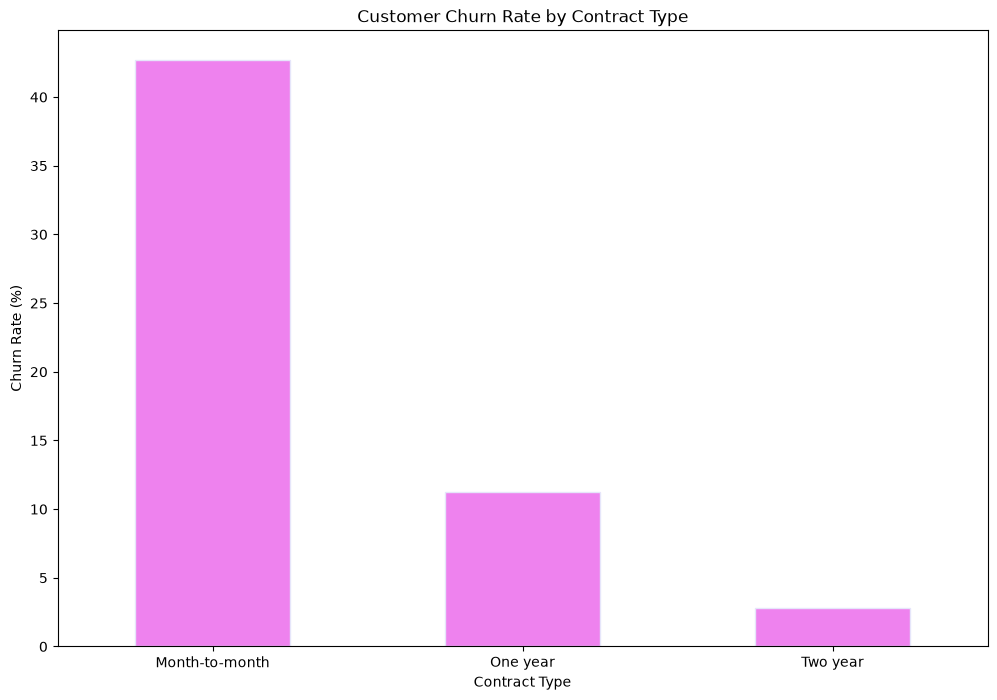

In [154]:
churn_by_contract['Yes'].sort_values(ascending=False).plot(kind='bar',figsize=(12,8),color='violet',edgecolor='lavender',title='Customer Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation = 0)
plt.show()

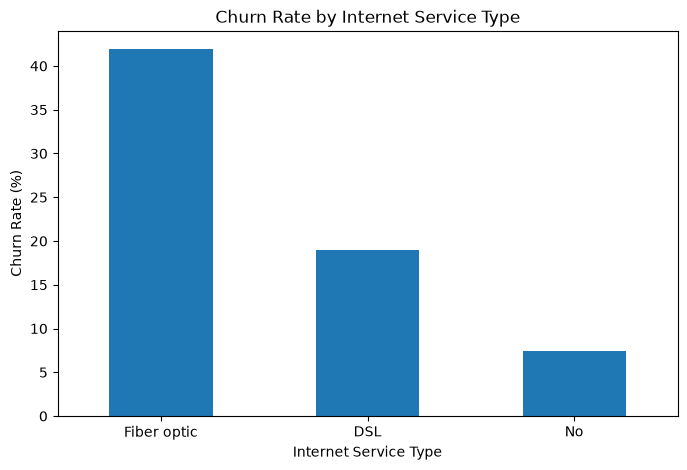

In [155]:
# Visualise how internet service relate to churn 
churn_by_internet['Yes'].sort_values(ascending=False).plot(kind='bar',
                                                           figsize=(8,5),
                                                           title='Churn Rate by Internet Service Type')
plt.xlabel("Internet Service Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

Fiber optic customers have a 41.9% churn rate, more than twice the 19.0% churn rate among DSL customers.

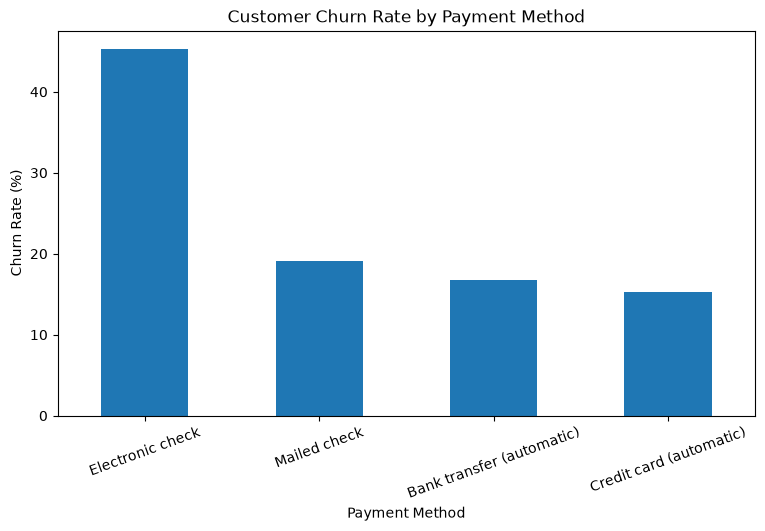

In [156]:
churn_by_payment["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(9, 5),
    title="Customer Churn Rate by Payment Method"
)

plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.show()

Electronic-check customers have the highest churn rate at 45.3%, while automatic credit-card customers have the lowest at 15.2%.That's about a 30 percentage-point gap, which is substantial.

In [157]:
churn_contract_internet = pd.crosstab(
    [df["Contract"], df["InternetService"]],
    df["Churn"],
    normalize="index"
) * 100

In [158]:
churn_contract_internet["Yes"].round(2)

Contract        InternetService
Month-to-month  DSL                32.22
                Fiber optic        54.61
                No                 18.89
One year        DSL                 9.30
                Fiber optic        19.29
                No                  2.47
Two year        DSL                 1.91
                Fiber optic         7.23
                No                  0.78
Name: Yes, dtype: float64

In [159]:
churn_contract_internet.reset_index(drop=True)

Churn,No,Yes
0,67.784137,32.215863
1,45.394737,54.605263
2,81.106870,18.893130
3,90.701754,9.298246
4,80.705009,19.294991
5,97.527473,2.472527
6,98.089172,1.910828
7,92.773893,7.226107
8,99.216301,0.783699


In [160]:
churn_contract_internet_clean=churn_contract_internet['Yes'].reset_index().rename(columns={'Yes':'ChurnRate'})

In [161]:
churn_contract_internet_clean

,Contract,InternetService,ChurnRate
0,Month-to-month,DSL,32.215863
1,Month-to-month,Fiber optic,54.605263
2,Month-to-month,No,18.893130
3,One year,DSL,9.298246
4,One year,Fiber optic,19.294991
5,One year,No,2.472527
6,Two year,DSL,1.910828
7,Two year,Fiber optic,7.226107
8,Two year,No,0.783699


Fiber optic has higher churn within every contract type, but the highest-risk combination is specifically month-to-month + fiber optic.

In [162]:
churn_contract_internet_clean['Segment']=churn_contract_internet_clean['Contract']+'+'+churn_contract_internet_clean['InternetService']

In [163]:
churn_contract_internet_clean

,Contract,InternetService,ChurnRate,Segment
0,Month-to-month,DSL,32.215863,Month-to-month+DSL
1,Month-to-month,Fiber optic,54.605263,Month-to-month+Fiber optic
2,Month-to-month,No,18.893130,Month-to-month+No
3,One year,DSL,9.298246,One year+DSL
4,One year,Fiber optic,19.294991,One year+Fiber optic
5,One year,No,2.472527,One year+No
6,Two year,DSL,1.910828,Two year+DSL
7,Two year,Fiber optic,7.226107,Two year+Fiber optic
8,Two year,No,0.783699,Two year+No


In [164]:
churn_contract_internet_clean=churn_contract_internet_clean.sort_values('ChurnRate',ascending=False)

In [167]:
churn_contract_internet_clean.reset_index(drop=True)

,Contract,InternetService,ChurnRate,Segment
0,Month-to-month,Fiber optic,54.605263,Month-to-month+Fiber optic
1,Month-to-month,DSL,32.215863,Month-to-month+DSL
2,One year,Fiber optic,19.294991,One year+Fiber optic
3,Month-to-month,No,18.893130,Month-to-month+No
4,One year,DSL,9.298246,One year+DSL
5,Two year,Fiber optic,7.226107,Two year+Fiber optic
6,One year,No,2.472527,One year+No
7,Two year,DSL,1.910828,Two year+DSL
8,Two year,No,0.783699,Two year+No


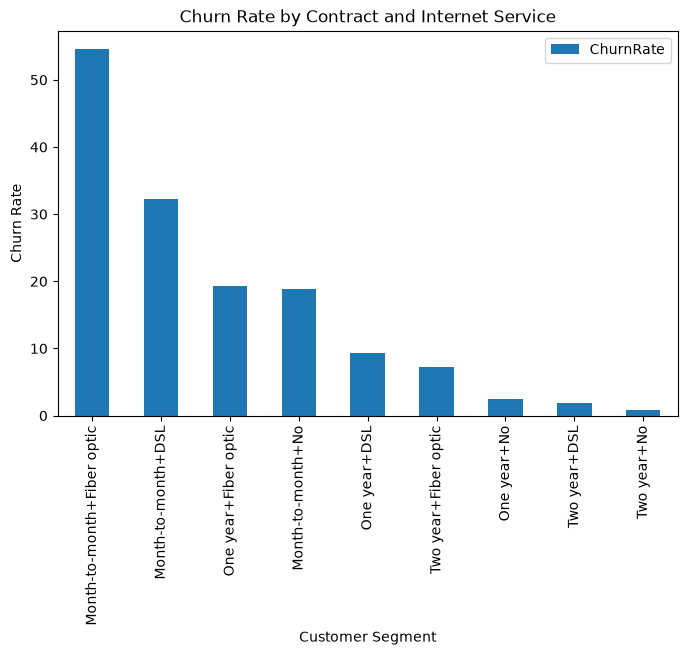

In [168]:
churn_contract_internet_clean.plot(kind='bar',x='Segment', y='ChurnRate', figsize=(8,5),title='Churn Rate by Contract and Internet Service')
plt.xlabel('Customer Segment')
plt.ylabel('Churn Rate')
plt.show()

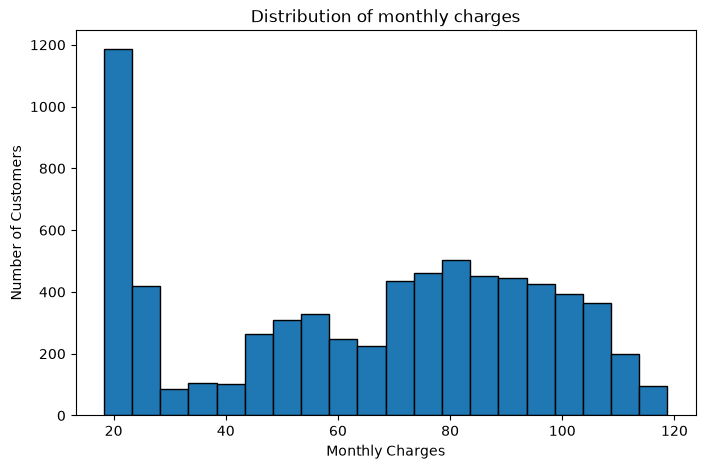

In [171]:
# How are customers distributed across different monthly-charge ranges?
df['MonthlyCharges'].plot(kind='hist',
                          figsize=(8,5),
                          title='Distribution of monthly charges',
                          edgecolor='black',
                          bins=20)
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

Does the distribution of MonthlyCharges look different for customers who churned versus customers who stayed?

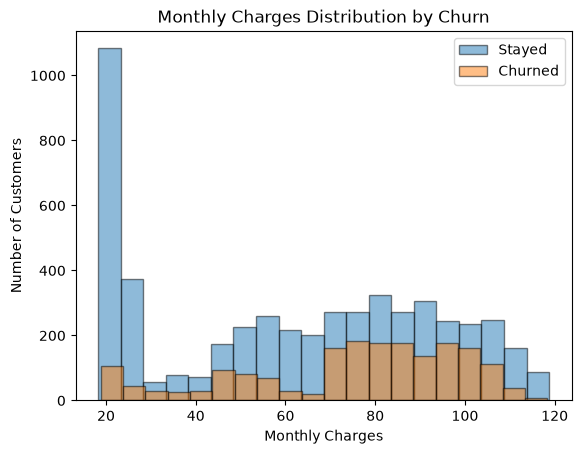

In [174]:
# Do churned and non-churned customers have different MonthlyCharges distributions?
df[df['Churn']=='No']['MonthlyCharges'].plot(
    kind='hist',
    bins=20,
    alpha=0.5,
    label='Stayed',
    edgecolor='black'
)
df[df['Churn']=='Yes']['MonthlyCharges'].plot(
    kind='hist',
    bins=20,
    alpha=0.5,
    label='Churned',
    edgecolor='black'
)

plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.title('Monthly Charges Distribution by Churn')
plt.legend()
plt.show()

The churned group is more concentrated toward higher monthly-charge ranges than the stayed group.

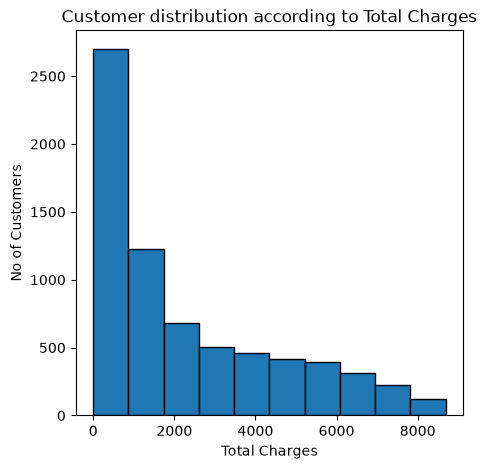

In [176]:
# How are customers distributed according to the total amount they've been charged over their time with the company?
df['TotalCharges'].plot(
    kind='hist',
    figsize=(5,5),
    title='Customer distribution according to Total Charges',
    edgecolor='black'
)
plt.xlabel('Total Charges')
plt.ylabel('No of Customers')
plt.show()

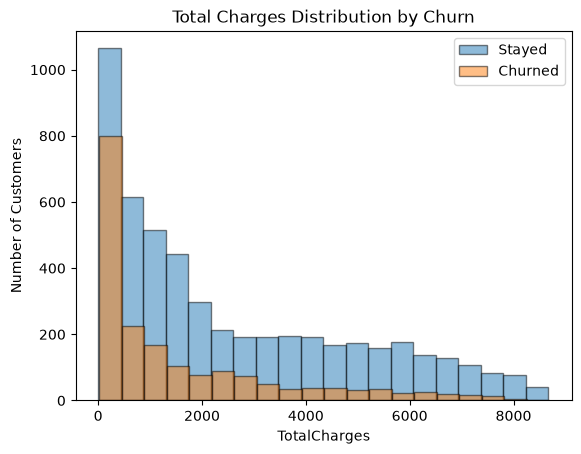

In [180]:
# Does the TotalCharges distribution look different for customers who stayed versus customers who churned?

df[df['Churn']=='No']['TotalCharges'].plot(
    kind ='hist',
    bins=20,
    label='Stayed',
    alpha=0.5,
    edgecolor='black'
)
df[df['Churn']=='Yes']['TotalCharges'].plot(
    kind='hist',
    bins=20,
    alpha=0.5,
    label='Churned',
    edgecolor='black'
)

plt.xlabel('TotalCharges')
plt.ylabel('Number of Customers')
plt.title('Total Charges Distribution by Churn')
plt.legend()
plt.show()

As TotalCharges increase, the number of customers decreases.
Shorter tenure → less accumulated TotalCharges → higher likelihood of churn

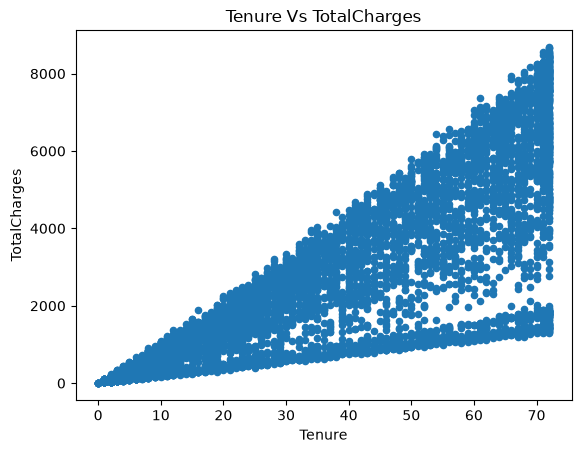

In [182]:
# As customer tenure increases, do TotalCharges generally increase?
df.plot(
    kind='scatter',
    x='tenure',
    y='TotalCharges',
    title='Tenure Vs TotalCharges'
)

plt.xlabel('Tenure')
plt.ylabel('TotalCharges')
plt.show()

As tenure increases, TotalCharges generally increase.

The points don't form one perfectly straight line. They spread out more as tenure increases.That's because customers can have different MonthlyCharges.

Short tenure
→ less time with company
→ lower TotalCharges
→ also associated with higher churn

In [183]:
# Check remaining variables 
pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


Gender does not appear to be a meaningful churn differentiator in this dataset.

In [184]:
pd.crosstab(
    df["OnlineBackup"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
OnlineBackup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


Customers without Online Backup show a substantially higher observed churn rate than customers with Online Backup.


**So service/support features are starting to look like an important part of our churn story.**

In [185]:
pd.crosstab(
    df["DeviceProtection"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
DeviceProtection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064


Customers without DeviceProtection show a substantially higher observed churn rate than customers with DeviceProtection.

In [186]:
pd.crosstab(
    df["StreamingTV"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
StreamingTV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


StreamingTV does not appear to be a major churn differentiator in this dataset.

In [187]:
pd.crosstab(
    df["StreamingMovies"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
StreamingMovies,,
No,66.319569,33.680431
No internet service,92.595020,7.404980
Yes,70.058565,29.941435


StreamingMovies does not appear to be a major churn differentiator.

In [188]:
pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


Customers with PaperlessBilling show a substantially higher observed churn rate than customers without it.

# EDA Summary and Key Findings

After completing the exploratory data analysis, we examined both individual variables and combinations of variables to understand which customer characteristics are associated with churn.

## 1. Overall Churn

The dataset contains 7,043 customers.

- Customers who stayed: 5,174 (73.46%)
- Customers who churned: 1,869 (26.54%)

Therefore, the overall churn rate is:

**26.54%**

This serves as our baseline for comparing different customer segments.

---

## 2. Contract Type

Contract type shows one of the strongest relationships with churn.

| Contract Type | Churn Rate |
|---|---:|
| Month-to-month | 42.71% |
| One year | 11.27% |
| Two year | 2.83% |

### Finding

Month-to-month customers show substantially higher observed churn than customers on longer-term contracts.

This suggests that contract type is an important churn differentiator.

> Important: These results show an association, not causation. We cannot conclude that month-to-month contracts cause customers to churn.

---

## 3. Tenure

Churned customers have substantially shorter average tenure.

| Churn Status | Average Tenure |
|---|---:|
| Stayed | 37.57 months |
| Churned | 17.98 months |

When customers were grouped into tenure ranges, we found:

- 0–12 months → roughly 47% churn
- 61–72 months → roughly 6% churn

### Finding

Churn generally decreases as customer tenure increases.

Newer customers appear to be a particularly important high-churn segment.

---

## 4. Internet Service

Internet service type also shows a meaningful relationship with churn.

Fiber optic customers have a substantially higher observed churn rate than DSL and customers without internet service.

This becomes even more interesting when Internet Service is combined with Contract Type.

---

## 5. Contract + Internet Service

We examined churn rates for combinations of Contract and Internet Service.

| Contract + Internet Service | Churn Rate |
|---|---:|
| Month-to-month + Fiber optic | **54.61%** |
| Month-to-month + DSL | 32.22% |
| Month-to-month + No internet | 18.89% |
| One year + Fiber optic | 19.29% |
| One year + DSL | 9.30% |
| One year + No internet | 2.47% |
| Two year + Fiber optic | 7.23% |
| Two year + DSL | 1.91% |
| Two year + No internet | 0.78% |

### Finding

**Month-to-month + Fiber optic customers have the highest observed churn rate at approximately 54.61%.**

This demonstrates why analysing combinations of variables can reveal important customer segments that may not be as obvious when looking at individual variables.

---

## 6. Payment Method

| Payment Method | Churn Rate |
|---|---:|
| Electronic check | **45.3%** |
| Mailed check | 19.1% |
| Bank transfer | 16.7% |
| Credit card | 15.2% |

### Finding

Electronic-check customers show the highest observed churn rate.

We also examined Contract + Payment Method.

The highest combination was:

**Month-to-month + Electronic check → 53.7% churn**

Again, this represents an observed association rather than causation.

---

## 7. Online Security

Customers without Online Security show substantially higher observed churn.

| Online Security | Churn Rate |
|---|---:|
| No | 41.77% |
| Yes | 14.61% |
| No internet service | 7.40% |

### Finding

Customers without Online Security have a much higher observed churn rate than customers with Online Security.

---

## 8. Tech Support

| Tech Support | Churn Rate |
|---|---:|
| No | 41.60% |
| Yes | 15.20% |
| No internet service | 7.40% |

### Finding

Customers without Tech Support show substantially higher observed churn.

Among customers with internet service:

- Tech Support = No → 41.6%
- Tech Support = Yes → 15.2%

---

## 9. Online Backup

| Online Backup | Churn Rate |
|---|---:|
| No | 39.93% |
| Yes | 21.53% |
| No internet service | 7.40% |

### Finding

Customers without Online Backup show a substantially higher observed churn rate than customers with Online Backup.

---

## 10. Device Protection

| Device Protection | Churn Rate |
|---|---:|
| No | 39.13% |
| Yes | 22.50% |
| No internet service | 7.40% |

### Finding

Customers without Device Protection show a substantially higher observed churn rate than customers with Device Protection.

---

## 11. Tech Support + Online Security

We also examined the combination of Tech Support and Online Security.

| Tech Support + Online Security | Churn Rate |
|---|---:|
| No Tech Support + No Online Security | **48.96%** |
| No Tech Support + Yes Online Security | 21.30% |
| Yes Tech Support + No Online Security | 22.32% |
| Yes Tech Support + Yes Online Security | **9.01%** |

### Finding

Customers with both Tech Support and Online Security have much lower observed churn than customers with neither service.

---

## 12. Senior Citizen

| Senior Citizen | Churn Rate |
|---|---:|
| No | 23.61% |
| Yes | 41.68% |

### Finding

Senior customers show a substantially higher observed churn rate.

---

## 13. Dependents

| Dependents | Churn Rate |
|---|---:|
| No | 31.28% |
| Yes | 15.45% |

### Finding

Customers without dependents show roughly twice the observed churn rate of customers with dependents.

---

## 14. Paperless Billing

| Paperless Billing | Churn Rate |
|---|---:|
| No | 16.33% |
| Yes | 33.57% |

### Finding

Customers using Paperless Billing show a substantially higher observed churn rate.

This is an association and does not mean Paperless Billing itself causes churn.

---

# Variables with Weak Relationships

Not every variable showed a meaningful difference in churn.

### Gender

- Female → 26.92%
- Male → 26.16%

Difference: approximately **0.76 percentage points**

Gender does not appear to be a meaningful churn differentiator.

### Phone Service

- No phone service → 25%
- Phone service → 27%

Difference: approximately **2 percentage points**

Phone Service does not appear to have a strong relationship with churn.

### Multiple Lines

- No → 25%
- No phone service → 25%
- Yes → 29%

The difference is relatively small.

MultipleLines does not appear to be a major churn differentiator.

### Streaming TV

Among customers with internet service:

- No → 33.52%
- Yes → 30.07%

Difference: approximately **3.45 percentage points**

StreamingTV does not appear to be a major churn differentiator.

### Streaming Movies

Among customers with internet service:

- No → 33.68%
- Yes → 29.94%

Difference: approximately **3.74 percentage points**

StreamingMovies does not appear to be a major churn differentiator.

These variables were still analysed, but they do not need to be major parts of the final business story.

---

# Numerical Variable Analysis

## 15. Monthly Charges

The MonthlyCharges histogram showed that customers are distributed across different monthly-charge ranges, with a particularly large concentration at the lower end.

When comparing customers who stayed and customers who churned:

| Churn Status | Average Monthly Charges |
|---|---:|
| Stayed | $61.27 |
| Churned | $74.44 |

### Finding

Churned customers have higher average MonthlyCharges than customers who stayed.

The distribution also shows greater concentration of churned customers in higher monthly-charge ranges.

---

## 16. Total Charges

The TotalCharges distribution is heavily concentrated toward lower values.

The largest concentration is approximately in the $0–$1,000 range.

Average TotalCharges:

| Churn Status | Average Total Charges |
|---|---:|
| Stayed | $2,549.91 |
| Churned | $1,531.80 |

### Finding

Churned customers have lower average TotalCharges than customers who stayed.

This makes sense when considered alongside tenure because customers who leave earlier have had less time to accumulate total charges.

---

## 17. Tenure vs Total Charges

A scatter plot was used to examine the relationship between tenure and TotalCharges.

### Finding

There is a strong positive relationship between tenure and TotalCharges.

In general:

**Higher tenure → Higher TotalCharges**

However, customers with similar tenure can still have different TotalCharges because their MonthlyCharges can differ.

This helps explain why churned customers can have:

- Higher MonthlyCharges
- But lower TotalCharges

because churned customers generally have much shorter tenure.

---

# Key EDA Business Insights

The exploratory analysis reveals several important patterns.

### Highest-risk observed segments

1. **Month-to-month + Fiber optic → 54.61% churn**
2. **Month-to-month + Electronic check → 53.7% churn**
3. Customers without both Tech Support and Online Security → **48.96% churn**
4. Month-to-month customers overall → **42.71% churn**
5. Electronic-check customers → **45.3% churn**
6. Newer customers, especially those with 0–12 months tenure → roughly **47% churn**

### Strong recurring pattern

Customers with services such as:

- Online Security
- Tech Support
- Online Backup
- Device Protection

generally show lower observed churn rates than customers without those services.

### Overall business story

The strongest pattern emerging from the EDA is that churn is particularly high among **newer customers on month-to-month contracts**, especially when combined with **fiber optic service or electronic-check payment**.

Customers without certain support and security services also show substantially higher observed churn.

At the same time, variables such as Gender, PhoneService, MultipleLines, StreamingTV, and StreamingMovies show relatively weak differences and therefore should not be major parts of the final churn story.

> **Important analytical note:** All of these findings represent associations observed in the dataset. They do not prove that any individual factor directly causes customer churn.

# EDA Conclusion

The exploratory analysis is now complete.

We have examined:

- Overall churn
- Categorical variables
- Numerical variables
- Customer tenure
- MonthlyCharges
- TotalCharges
- Relationships between numerical variables
- Combinations of important categorical variables
- Strong and weak churn differentiators

The key findings from EDA will now be used to guide the next phase of the project: **SQL-based analysis and business questioning.**